# Dataset2 Analysis - Scraped News Articles

This notebook analyzes the scraped news articles from Fox News and Vice for COMP 451 Project #2 (NER with Prompt Engineering).


In [13]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


In [14]:
# Load data (cleaned - subscription entries removed)
with open('raw_articles.json', 'r', encoding='utf-8') as f:
    articles_data = json.load(f)

with open('raw_paragraphs.json', 'r', encoding='utf-8') as f:
    paragraphs_data = json.load(f)

articles = articles_data['articles']
paragraphs = paragraphs_data['articles']

print(f"Loaded {len(articles)} articles and {len(paragraphs)} paragraphs")
print(f"Metadata - Articles: {articles_data['metadata']['total_articles']}, Paragraphs: {paragraphs_data['metadata']['total_articles']}")
print(f"Sources: {articles_data['metadata']['source_counts']}")
print(f"\nNote: Subscription-related entries have been removed from the dataset.")


Loaded 30 articles and 551 paragraphs
Metadata - Articles: 30, Paragraphs: 551
Sources: {'Vice': 15, 'Fox News': 15}

Note: Subscription-related entries have been removed from the dataset.


## 1. Basic Statistics


In [15]:
# Article statistics
print("="*60)
print("ARTICLE STATISTICS")
print("="*60)
print(f"Total articles: {len(articles)}")
print(f"Sources: {articles_data['metadata']['source_counts']}")
print(f"\nScraped date: {articles_data['metadata']['scraped_date']}")

# Article lengths
article_lengths = [len(a['text']) for a in articles]
article_word_counts = [len(a['text'].split()) for a in articles]

print(f"\nArticle Text Length:")
print(f"  Total characters: {sum(article_lengths):,}")
print(f"  Average: {np.mean(article_lengths):.0f} chars")
print(f"  Median: {np.median(article_lengths):.0f} chars")
print(f"  Min: {min(article_lengths)} chars")
print(f"  Max: {max(article_lengths)} chars")

print(f"\nArticle Word Count:")
print(f"  Total words: {sum(article_word_counts):,}")
print(f"  Average: {np.mean(article_word_counts):.0f} words")
print(f"  Median: {np.median(article_word_counts):.0f} words")
print(f"  Min: {min(article_word_counts)} words")
print(f"  Max: {max(article_word_counts)} words")


ARTICLE STATISTICS
Total articles: 30
Sources: {'Vice': 15, 'Fox News': 15}

Scraped date: 2025-12-19T20:10:05.518957

Article Text Length:
  Total characters: 123,928
  Average: 4131 chars
  Median: 3625 chars
  Min: 1637 chars
  Max: 15135 chars

Article Word Count:
  Total words: 19,860
  Average: 662 words
  Median: 581 words
  Min: 270 words
  Max: 2510 words


In [16]:
# Paragraph statistics
print("="*60)
print("PARAGRAPH STATISTICS")
print("="*60)
print(f"Total paragraphs: {len(paragraphs)}")
print(f"Sources: {paragraphs_data['metadata']['source_counts']}")

# Paragraph lengths
para_lengths = [len(p['text']) for p in paragraphs]
para_word_counts = [len(p['text'].split()) for p in paragraphs]

print(f"\nParagraph Text Length:")
print(f"  Total characters: {sum(para_lengths):,}")
print(f"  Average: {np.mean(para_lengths):.0f} chars")
print(f"  Median: {np.median(para_lengths):.0f} chars")
print(f"  Min: {min(para_lengths)} chars")
print(f"  Max: {max(para_lengths)} chars")

print(f"\nParagraph Word Count:")
print(f"  Average: {np.mean(para_word_counts):.0f} words")
print(f"  Median: {np.median(para_word_counts):.0f} words")
print(f"  Min: {min(para_word_counts)} words")
print(f"  Max: {max(para_word_counts)} words")


PARAGRAPH STATISTICS
Total paragraphs: 551
Sources: {'Vice': 158, 'Fox News': 393}

Paragraph Text Length:
  Total characters: 117,506
  Average: 213 chars
  Median: 185 chars
  Min: 54 chars
  Max: 1132 chars

Paragraph Word Count:
  Average: 34 words
  Median: 30 words
  Min: 8 words
  Max: 196 words


## 2. Source Distribution


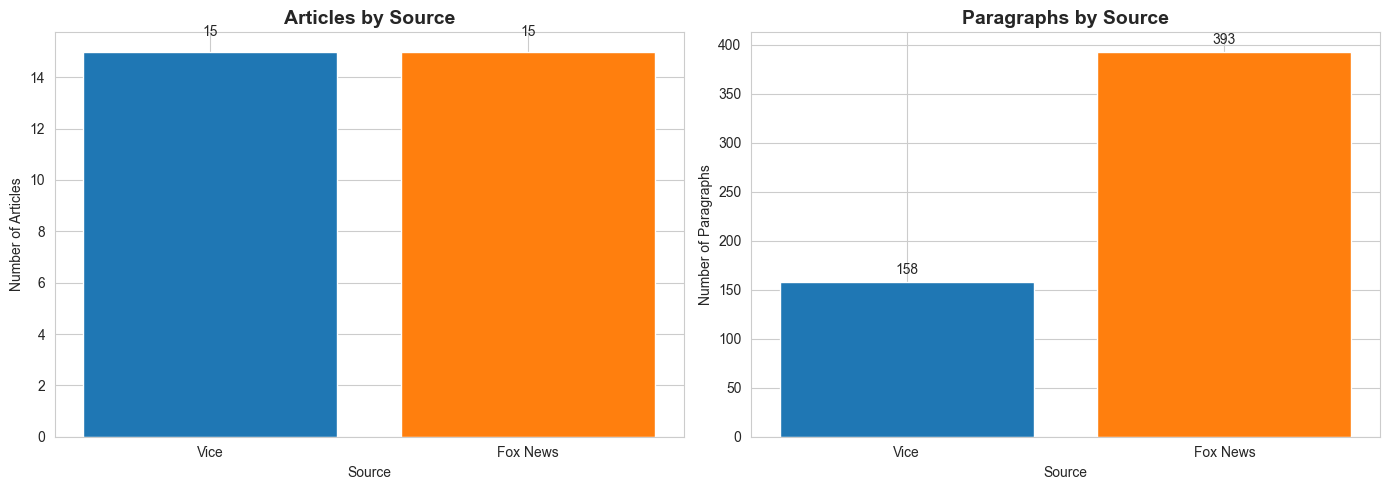

In [17]:
# Source distribution for articles
source_counts_articles = Counter([a['source'] for a in articles])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Articles by source
sources_art = list(source_counts_articles.keys())
counts_art = list(source_counts_articles.values())
ax1.bar(sources_art, counts_art, color=['#1f77b4', '#ff7f0e'])
ax1.set_title('Articles by Source', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Articles')
ax1.set_xlabel('Source')
for i, v in enumerate(counts_art):
    ax1.text(i, v + 0.5, str(v), ha='center', va='bottom')

# Paragraphs by source
source_counts_paras = Counter([p['source'] for p in paragraphs])
sources_para = list(source_counts_paras.keys())
counts_para = list(source_counts_paras.values())
ax2.bar(sources_para, counts_para, color=['#1f77b4', '#ff7f0e'])
ax2.set_title('Paragraphs by Source', fontsize=14, fontweight='bold')
ax2.set_ylabel('Number of Paragraphs')
ax2.set_xlabel('Source')
for i, v in enumerate(counts_para):
    ax2.text(i, v + 5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()


## 3. Text Length Distributions


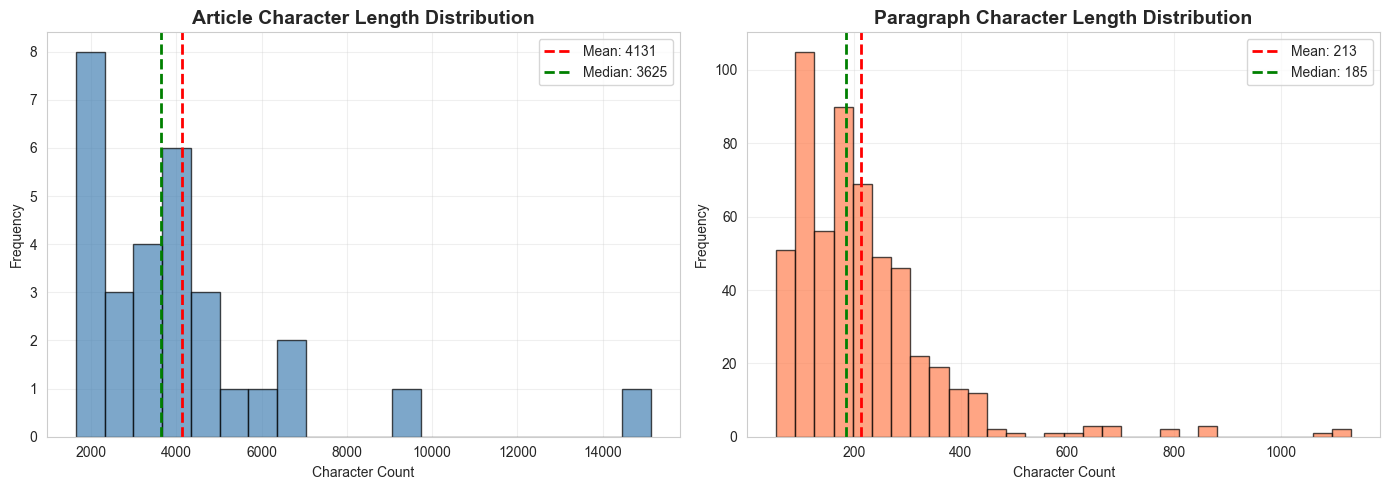

In [18]:
# Article length distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Article character length
ax1.hist(article_lengths, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(np.mean(article_lengths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(article_lengths):.0f}')
ax1.axvline(np.median(article_lengths), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(article_lengths):.0f}')
ax1.set_title('Article Character Length Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Character Count')
ax1.set_ylabel('Frequency')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Paragraph character length
ax2.hist(para_lengths, bins=30, color='coral', edgecolor='black', alpha=0.7)
ax2.axvline(np.mean(para_lengths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(para_lengths):.0f}')
ax2.axvline(np.median(para_lengths), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(para_lengths):.0f}')
ax2.set_title('Paragraph Character Length Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Character Count')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Source Comparison


Article Lengths by Source:
           char_count                       word_count                  
                 mean  median   min    max        mean median  min   max
source                                                                  
Fox News  5037.266667  4910.0  3484   9195  787.266667  750.0  509  1432
Vice      3224.600000  2177.0  1637  15135  536.733333  362.0  270  2510


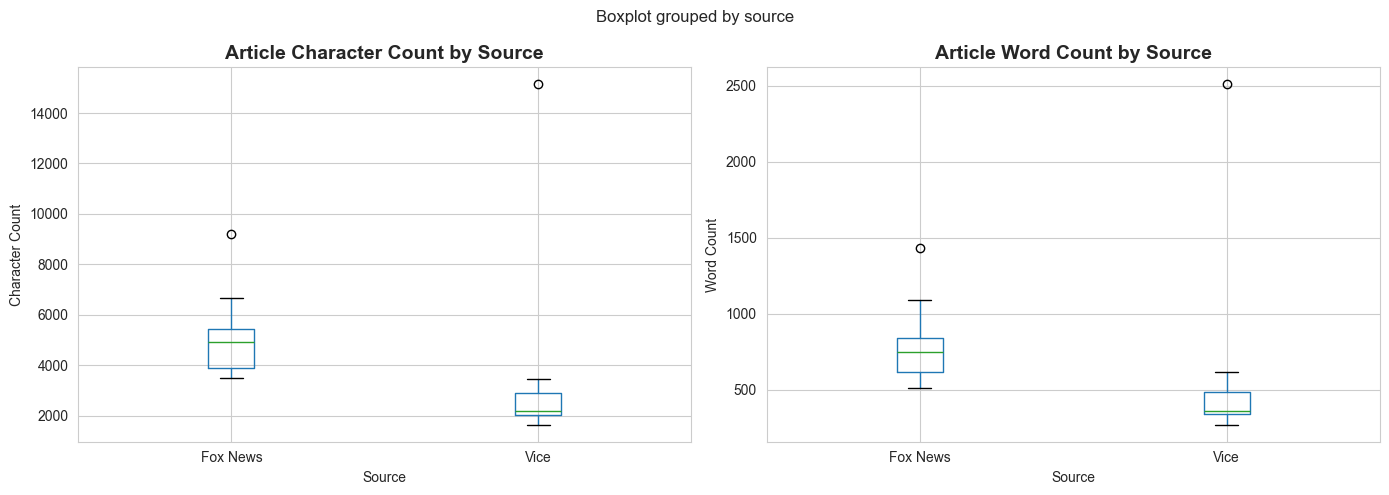

In [19]:
# Compare article lengths by source
df_articles = pd.DataFrame(articles)
df_articles['char_count'] = df_articles['text'].str.len()
df_articles['word_count'] = df_articles['text'].str.split().str.len()

print("Article Lengths by Source:")
print(df_articles.groupby('source')[['char_count', 'word_count']].agg(['mean', 'median', 'min', 'max']))

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Character count by source
df_articles.boxplot(column='char_count', by='source', ax=ax1)
ax1.set_title('Article Character Count by Source', fontsize=14, fontweight='bold')
ax1.set_xlabel('Source')
ax1.set_ylabel('Character Count')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# Word count by source
df_articles.boxplot(column='word_count', by='source', ax=ax2)
ax2.set_title('Article Word Count by Source', fontsize=14, fontweight='bold')
ax2.set_xlabel('Source')
ax2.set_ylabel('Word Count')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()


Paragraph Lengths by Source:
          char_count                  word_count                
                mean median min   max       mean median min  max
source                                                          
Fox News  176.849873  167.0  54   430  27.839695   26.0   8   72
Vice      303.822785  259.0  58  1132  50.879747   43.0  10  196


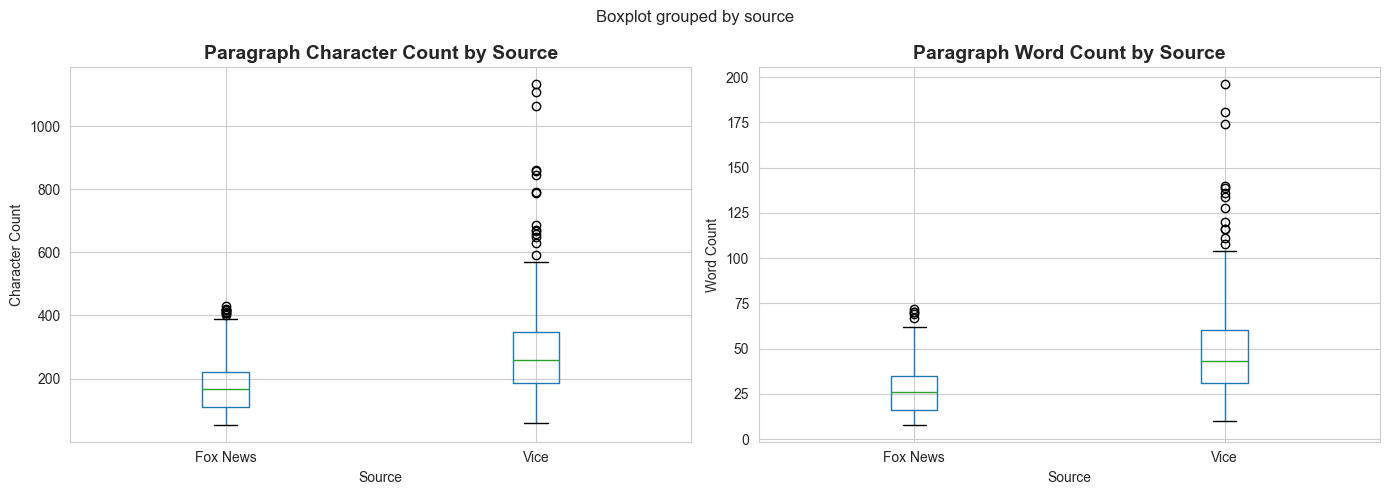

In [20]:
# Compare paragraph lengths by source
df_paragraphs = pd.DataFrame(paragraphs)
df_paragraphs['char_count'] = df_paragraphs['text'].str.len()
df_paragraphs['word_count'] = df_paragraphs['text'].str.split().str.len()

print("Paragraph Lengths by Source:")
print(df_paragraphs.groupby('source')[['char_count', 'word_count']].agg(['mean', 'median', 'min', 'max']))

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Character count by source
df_paragraphs.boxplot(column='char_count', by='source', ax=ax1)
ax1.set_title('Paragraph Character Count by Source', fontsize=14, fontweight='bold')
ax1.set_xlabel('Source')
ax1.set_ylabel('Character Count')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# Word count by source
df_paragraphs.boxplot(column='word_count', by='source', ax=ax2)
ax2.set_title('Paragraph Word Count by Source', fontsize=14, fontweight='bold')
ax2.set_xlabel('Source')
ax2.set_ylabel('Word Count')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()


## 5. Category Analysis


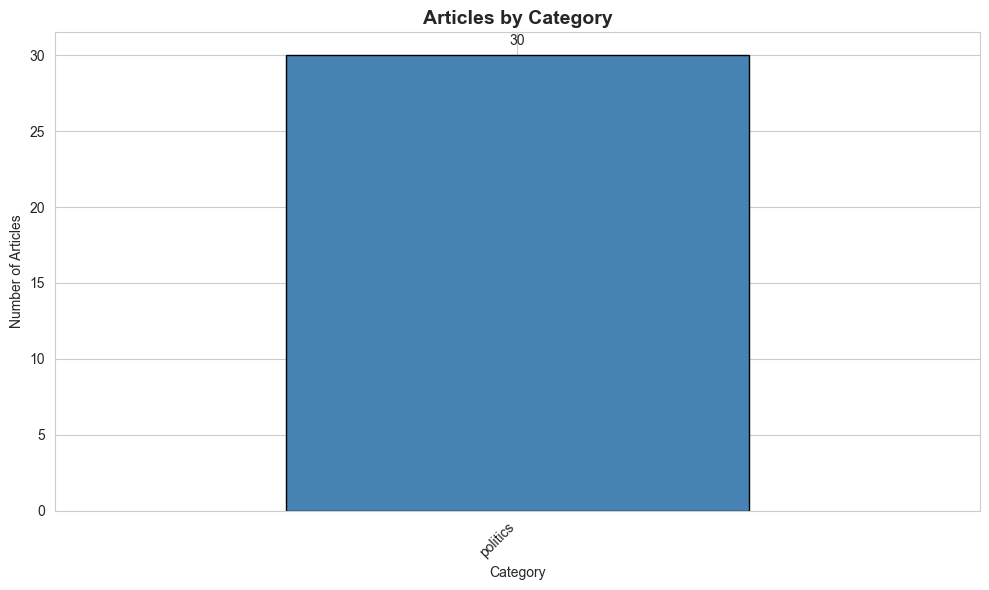


Category Distribution:
category
politics    30
Name: count, dtype: int64


In [21]:
# Category distribution
if 'category' in df_articles.columns:
    category_counts = df_articles['category'].value_counts()
    
    plt.figure(figsize=(10, 6))
    category_counts.plot(kind='bar', color=['steelblue', 'coral'], edgecolor='black')
    plt.title('Articles by Category', fontsize=14, fontweight='bold')
    plt.xlabel('Category')
    plt.ylabel('Number of Articles')
    plt.xticks(rotation=45, ha='right')
    for i, v in enumerate(category_counts):
        plt.text(i, v + 0.5, str(v), ha='center', va='bottom')
    plt.tight_layout()
    plt.show()
    
    print("\nCategory Distribution:")
    print(category_counts)


## 6. Sample Articles


In [22]:
# Display sample articles from each source
print("="*60)
print("SAMPLE ARTICLES")
print("="*60)

for source in df_articles['source'].unique():
    print(f"\n{source}:")
    sample = df_articles[df_articles['source'] == source].iloc[0]
    print(f"  Title: {sample['title']}")
    print(f"  URL: {sample['url']}")
    print(f"  Length: {sample['char_count']} chars, {sample['word_count']} words")
    print(f"  Preview: {sample['text'][:200]}...")


SAMPLE ARTICLES

Vice:
  Title: This AI Chatbot Minister Just Announced It’s ‘Pregnant’. Seriously.
  URL: https://www.vice.com/en/article/this-ai-chatbot-minister-just-announced-its-pregnant-seriously/
  Length: 2166 chars, 362 words
  Preview: You probably don’t pay much attention to Albanian political news, so let me give you a quick summation of what’s going on over there. The Albanian government recently appointed an AI chatbot as a mini...

Fox News:
  Title: Deadly strike on US troops tests Trump’s counter-ISIS plan — and his trust in Syria’s new leader
  URL: https://www.foxnews.com/politics/deadly-strike-u-s-troops-tests-trumps-counter-isis-plan-his-trust-syrias-new-leader
  Length: 9195 chars, 1432 words
  Preview: Fox News chief national security correspondent Jennifer Griffin has the latest on the two National Guardsmen killed in Syria on 'America Reports.'

A deadly insider attack that killed two U.S. service...


## 7. Entity-Rich Content Check


Entity Indicators Found in Paragraphs:
  Person: 98 occurrences (17.8% of paragraphs)
  Location: 35 occurrences (6.4% of paragraphs)
  Organization: 35 occurrences (6.4% of paragraphs)
  Time: 80 occurrences (14.5% of paragraphs)
  Currency: 41 occurrences (7.4% of paragraphs)


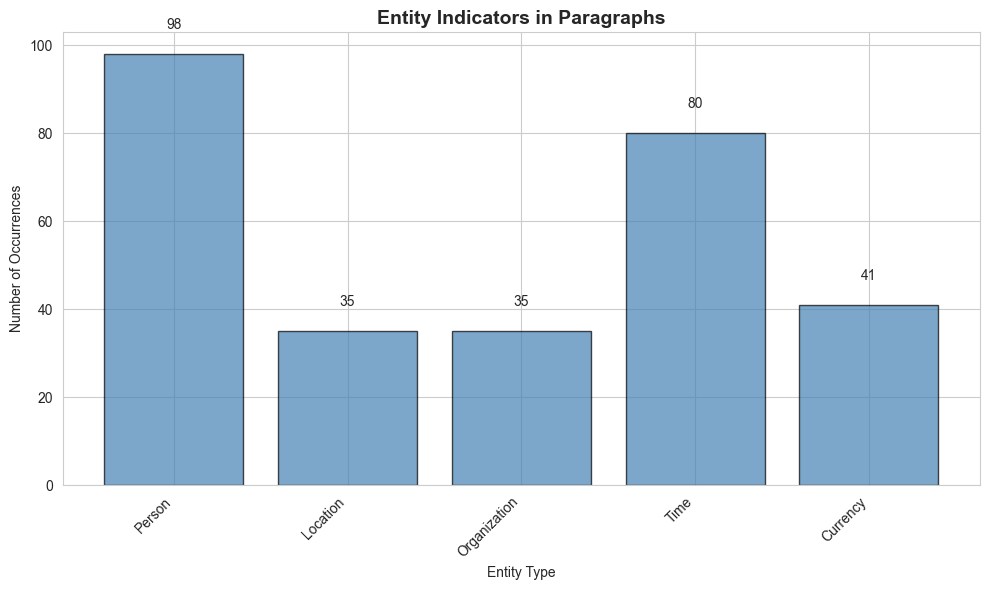

In [23]:
# Check for entity indicators (simple heuristic)
entity_indicators = {
    'Person': ['President', 'Senator', 'Rep.', 'Mr.', 'Ms.', 'Dr.', 'CEO', 'Inc.', 'Corp.', 'Ltd.'],
    'Location': ['Washington', 'New York', 'California', 'Texas', 'London', 'Paris'],
    'Organization': ['Inc.', 'Corp.', 'Ltd.', 'Company', 'Organization', 'Department'],
    'Time': ['January', 'February', 'March', '2024', '2025', 'Monday', 'Tuesday', 'today', 'yesterday'],
    'Currency': ['$', 'dollar', 'million', 'billion', 'USD', 'euro']
}

def count_entity_indicators(text, entity_type):
    text_lower = text.lower()
    return sum(1 for indicator in entity_indicators[entity_type] if indicator.lower() in text_lower)

# Analyze paragraphs
entity_counts = {}
for entity_type in entity_indicators.keys():
    entity_counts[entity_type] = sum(count_entity_indicators(p['text'], entity_type) for p in paragraphs)

print("Entity Indicators Found in Paragraphs:")
for entity_type, count in entity_counts.items():
    percentage = (count / len(paragraphs)) * 100
    print(f"  {entity_type}: {count} occurrences ({percentage:.1f}% of paragraphs)")

# Visualization
plt.figure(figsize=(10, 6))
entity_types = list(entity_counts.keys())
counts = list(entity_counts.values())
plt.bar(entity_types, counts, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Entity Indicators in Paragraphs', fontsize=14, fontweight='bold')
plt.xlabel('Entity Type')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(counts):
    plt.text(i, v + 5, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()


## 8. Summary Statistics


In [24]:
print("="*60)
print("DATASET2 SUMMARY")
print("="*60)
print(f"\nTotal Articles: {len(articles)}")
print(f"Total Paragraphs: {len(paragraphs)}")
print(f"\nSources:")
for source, count in source_counts_articles.items():
    print(f"  {source}: {count} articles")
print(f"\nParagraphs by Source:")
for source, count in source_counts_paras.items():
    print(f"  {source}: {count} paragraphs")
print(f"\nTotal Characters: {sum(article_lengths):,}")
print(f"Total Words: {sum(article_word_counts):,}")
print(f"\nAverage Article Length: {np.mean(article_lengths):.0f} chars ({np.mean(article_word_counts):.0f} words)")
print(f"Average Paragraph Length: {np.mean(para_lengths):.0f} chars ({np.mean(para_word_counts):.0f} words)")
print("="*60)


DATASET2 SUMMARY

Total Articles: 30
Total Paragraphs: 551

Sources:
  Vice: 15 articles
  Fox News: 15 articles

Paragraphs by Source:
  Vice: 158 paragraphs
  Fox News: 393 paragraphs

Total Characters: 123,928
Total Words: 19,860

Average Article Length: 4131 chars (662 words)
Average Paragraph Length: 213 chars (34 words)
